# PRVI SEMINARSKI RAD 2026

#### KOLEGIJ: Napredna teorija algoritama i sustava

#### Datum predaje rada: 7. svibnja 2026.

#### Broj tima: TIM_02

#### Ime i prezime članova tima

| # | Član | Uloga | Obrađeni dijelovi zadatka |
|---|---|---|---|
| 1 | **Matej Fajt** | voditelj tima | generator sintetskog skupa, a) učitavanje, b) izgradnja, c) min/max |
| 2 | Tin Bukovina | član | d) brojači rotacija, e) ispis po razinama, implementacija crveno-crnog stabla |
| 3 | Patrik Ostrunić | član | f) prefiks pretraga, g) range pretraga |
| 4 | Filip Kušer | član | h) sortiranja, i) primjena na datum rođenja i mjesto stanovanja, integracija notebooka |


## POSTUPAK


 1.	Preuzimanje zadataka (po timovima) iz LMS-a predmeta.
 2.	Rješenja zadataka u Jupyter Notebook obliku (tekstualni opis, kod,  rezultati, diskusija i zaključak) ili DOCX obliku uz priloženu implementaciju prema danom predlošku predati kao datoteku pod nazivom SEM1_TIMxy (xy - broj tima) u LMS predmeta. Rješenje predaje samo jedan član tima.
 3. Rješenja zadataka treba predati do 7. svibnja 2026. u 23:59 u LMS sustav. 

# OPIS ZADATKA

Korištenjem AVL balansiranog stabla implementirati stablo za indeksiranje zapisa iz baze podataka. Baza podataka u obliku tekstualne datoteke sadrži zapise o osobama. Podatkovni skup je zadan u datoteci *data.csv* te se sastoji više stotina tisuća zapisa. 
Struktura zapisa u datoteci je:
*ime, prezime, spol, datum_rođenja, mjesto_stanovanja*


**Svaki tim će imati drugi skup zapisa za obradu.**

## ZADACI KOJE TREBA IMPLEMENTIRATI

a) Učitati podatke iz datoteke u odgovarajuću strukturu.

b) Na temelju sadržaja tekstualne datoteke treba izgraditi najprije obično pa onda i AVL binarno stablo pretraživanja uporabom razreda *BinaryTree* temeljem prezimena osobe kao primarnog indeksnog ključa te imena kao sekundarnog ključa. Ispisati visine dobivenih stabala. Usporediti vremena izgradnje.

c) Ispisati minimalnu i maksimalnu vrijednost indeksa i pripadnih podataka za te indekse.

d) Implementirati metode za ispis broja lijevih rotacija i broja desnih rotacija kod umetanja čvora u AVL stablo. Ispisati broj rotacija pri izgradnji AVL stabla.

e) Ispisati stabla po razinama gdje čvorove svake razine treba ispisati u zasebnom retku. S obzirom na veliku količinu podataka dovoljno je ispisati samo prvih 10 razina.

f) Implementirati pretraživanje podataka o osobama uporabom implementiranog indeksa i to tako da se za pretraživanje može zadati prezime u obliku prefiksa korištenjem znaka '\*'. Primjerice, može se unijeti cjelovito prezime 'Horvat' ili samo dio odnosno prefiks naziva 'Horv*'. Nakon što je podatak pronađen treba ispisati cijeli zapis o osobi. Usporediti vremena pretrage za obično i balansirano stablo.

g) Implementirati funkciju za traženje osoba u rangu prezimena, primjerice sve osobe od '*Horv*' do '*Ivo*', ili od '*D*' do '*I*'. Rangove treba moći zadati proizvoljno. Usporediti vremena pretrage za obično i balansirano stablo.

h) Sortirati zapise različitim algoritmima sortiranja uzevši kao ključ sortiranja prezime osobe. Ako dvije osobe imaju isto prezime kao drugi ključ sortiranja uzeti ime osobe. Usporediti algoritme po vremenu izvršavanja. Usporedbu vremena sortiranja potrebno je napraviti postepenim povećanjem nasumično izabranog podskupa zapisa koji se sortiraju: veličine 1000, 2000, 5000, 10000, 20000, 50000, 100000. Potrebno je implementirati i usporediti vremena sortiranja za algoritme sortiranja umetanjem, sortiranja spajanjem, brzog sortiranja i sortiranja balansiranim stablom. 

i) Ponoviti postupke b)-h) primijenivši datum rođenja i mjesto stanovanja kao indeksne ključeve (zasebno za svaki indeksni ključ).

Timovi od 3 člana će imati skup podataka za trećinu manji od timova s 4 člana. Timovi od 2 člana će imati skup podataka koji je duplo manji od timova s 3 člana. 
U zadatku i) timovi od 3 člana trebaju napraviti implementirati samo jedan dodatni indeksni ključ od navedena dva. Timovi od 2 člana ne trebaju raditi zadatak i).

Timovi mogu predložiti vlastitu podatkovni skup koji treba biti istog reda veličine kao i prvotno dodijeljeni te u tom slučaju timovi mogu dobiti 3 dodatna boda.
U slučaju da tim samostalno implementira navedene zadatke i za crveno-crno stablo to se može bodovati za još 3 dodatna boda.
Ukupan broj bodova na kolegiju je u svakom slučaju ograničen na ukupno 100 bodova.


# SADRŽAJ RADA

## Opis implementacije 



U seminaru je implementirano AVL balansirano binarno stablo za indeksiranje
zapisa o osobama (`ime`, `prezime`, `spol`, `datum_rođenja`, `mjesto_stanovanja`)
iz CSV datoteke koja sadrži **1 000 000 sintetskih zapisa s hrvatskim
imenima/prezimenima/gradovima** (atomski podaci preuzeti iz javnih izvora
DZS-a, kombinacije nasumične sa `random.seed(42)`).

**Napomena o podatkovnom skupu.** Kao dodatni dio rada koristi se
**vlastiti sintetski skup** umjesto dodijeljenog
`podatkovni_skup_Bukovina.csv` (1 000 000 zapisa). Sintetski skup
**strukturno i veličinski odgovara dodijeljenom skupu**:

- broj zapisa: 1 000 000 (isto)
- redoslijed stupaca: `ime, prezime, spol, datum_rođenja, mjesto_stanovanja`
- format datuma: `dd.mm.yyyy` (HR), kao u dodijeljenom
- bez header retka, kao u dodijeljenom

`load_dataset()` podržava sintetski skup i dodijeljeni
`podatkovni_skup_Bukovina.csv` iste sheme bez izmjena —
prepoznaje (ne)postojanje header retka i normalizira datum u ISO format
za korektno leksikografsko sortiranje.

Cijela implementacija nalazi se u ovom Jupyter notebooku, organizirano u
sljedeće logičke cjeline:

1. **Pomoćni razred `PersonRecord`** — `dataclass` s 5 polja koja
   odgovaraju shemi CSV-a.
2. **Indeksirani čvorovi (`IndexedNode` + tri varijante)** — nasljeđuju
   već zadani razred `BinaryNode` te nadjačavaju `compareTo` tako da uspoređuju
   ključ umjesto cijele vrijednosti. Tri varijante odgovaraju trima
   indeksnim ključevima:
   - `PrimaryKeyNode` — ključ `(prezime, ime)`
   - `DateKeyNode` — ključ `(datum_rodjenja, prezime, ime)`
   - `CityKeyNode` — ključ `(mjesto, prezime, ime)`
   Sekundarni dijelovi ključa služe kao tiebreaker da inorder traversal
   ostane deterministički.
3. **Obično (nebalansirano) BST** (`PlainBSTNode` mixin) — koristi isti
   `BinaryTree` infrastrukturu, ali nadjačava `add()` tako da preskoči
   AVL rotacije. Time se može direktno usporediti visine i vremena
   izgradnje s AVL-om, kako traži zadatak b).
4. **AVL s brojačima rotacija** (`make_counting_tree(...)`) — tvornička
   funkcija koja iz bilo koje `IndexedTree` podklase tvori varijantu
   koja prebrojava lijeve i desne rotacije pri umetanju (zadatak d).
   `LR` rotacija broji se kao 1 lijeva + 1 desna, `RL` analogno.
5. **Crveno-crno stablo** (`RBTree`, dodatni zadatak) — vlastita implementacija
   po CLRS varijanti, sa `NIL` sentinelom i postupkom popravljanja nakon
   inserta. Iste 3 ključne varijante (`RBPrimaryKeyTree`, `RBDateKeyTree`,
   `RBCityKeyTree`). Provedena je kroz cijeli set zadataka b)–h)
   paralelno s AVL-om.
6. **Sortiranja po prezimenu i imenu** — `insertion_sort`, `merge_sort`,
   `quick_sort` (s nasumičnim pivotom, iterativno radi izbjegavanja
   recursion limita), `tree_sort` (preko AVL-a). Svi su provjereni da
   daju **identičan rezultat na istom ulazu**.
7. **Generator sintetskog skupa** — koristi hardcodirane liste hrvatskih
   imena (M/Ž), prezimena i gradova preuzete iz DZS-a (Državni zavod za
   statistiku) te ih nasumično kombinira u zapise.
8. **Pomoćna funkcija `run_full_suite(...)`** — izvršava cijeli set
   zadataka b)–h) za zadani indeksni ključ. Poziva se 3× u notebooku:
   za primarni ključ (prezime+ime), za datum rođenja te za mjesto
   stanovanja (zadatak i, za 4-člani tim oba dodatna ključa).

**Analiza složenosti.** AVL i RB stablo imaju visinu *O(log N)*, pa su
operacije umetanja, pretrage i range-pretrage *O(log N)* po čvoru,
odnosno *O(log N + k)* za range-pretragu gdje je k broj rezultata.
Obično BST u prosječnom slučaju ima visinu *O(log N)* na slučajnim
ulazima ali bez garancije; u najgorem slučaju (sortirani ulaz) degradira
u *O(N)*. Sortiranja su *O(N²)* (insertion), *O(N log N)* (merge,
quick s nasumičnim pivotom u prosjeku, tree-sort).


## Prikaz rezultata

Ispitno okruženje provedeno je nad sintetskim skupom od **1 000 000
zapisa** generiranih sa `random.seed(42)`. Za svaki od triju indeksnih
ključeva (`prezime+ime`, `datum_rodjenja`, `mjesto_stanovanja`) izvedeni
su sljedeći testovi. Rezultati su prikazani u izvršenim ćelijama za
pojedini indeksni ključ.

- **b)** Izgradnja običnog BST-a, AVL-a i RB stabla; ispis visina i
  mjerenje vremena izgradnje (preko `time.perf_counter()`).
  Provjera AVL svojstva preko `assertAVLProperty()` — uvijek vraća
  `True`.
- **c)** Ispis najmanje i najveće vrijednosti indeksa (leftmost i
  rightmost u stablu) zajedno s pripadnim cjelovitim zapisima.
- **d)** Brojači lijevih i desnih rotacija pri izgradnji AVL stabla.
  LR rotacija = 1L + 1R; RL = 1R + 1L.
- **e)** Ispis stabla po razinama, prvih 10 razina; svaka razina u
  zasebnom retku. Pri svakoj razini ograničeno je na prvih 8 čvorova
  radi čitljivosti, s ispisom ukupnog broja čvorova na razini.
- **f)** Prefiks pretraga indeksom (uključujući prazno ime — npr.
  `'Horvat'` ili `'Horv*'`); usporedba vremena obična BST vs AVL vs RB.
- **g)** Range pretraga (npr. `'D'` do `'I'`); usporedba istih triju
  struktura.
- **h)** Sortiranje na rastućim podskupovima
  (1k, 2k, 5k, 10k, 20k, 50k, 100k) algoritmima insertion / merge /
  quick / tree-sort (preko AVL-a) / tree-sort (preko RB stabla kao
  dodatne usporedbe).
  Sve veličine pokrenute su za sve algoritme — insertion sort na 100k
  traje nekoliko minuta, što je u skladu s kvadratnom složenošću.

Ispitni slučajevi su izabrani da pokažu i tipične upite (česta hrvatska
prezimena/imena/gradovi) i rubne (kratki prefiksi koji vraćaju mnogo
rezultata, te potpuno specificirani upiti).


## Zaključak

Implementirana je AVL i crveno-crna varijanta balansiranog stabla,
te obična (nebalansirana) varijanta nad istim `BinaryTree` razredom.
Za ulaz od 1 000 000 sintetskih zapisa hrvatskih osoba dobivene su
sljedeće stvarne visine stabala i vremena izgradnje za svaki indeksni ključ:

- **Primarni ključ (prezime+ime)**: obični BST visina 134 i vrijeme
  10.863 s; AVL visina 23 i vrijeme 7.850 s; RB visina 25 i vrijeme
  4.955 s.
- **Datum rođenja**: obični BST visina 53 i vrijeme 11.052 s; AVL
  visina 23 i vrijeme 7.899 s; RB visina 24 i vrijeme 4.764 s.
- **Mjesto stanovanja**: obični BST visina 49 i vrijeme 9.971 s; AVL
  visina 23 i vrijeme 7.430 s; RB visina 23 i vrijeme 4.551 s.

AVL visina 23 za sva tri ključa vrlo je blizu teoretskoj donjoj granici
`⌈log₂(1 000 000)⌉ ≈ 20`; AVL svojstvo `|h(L) − h(R)| ≤ 1` provjereno je
preko `assertAVLProperty()` i u svim pokretanjima vraća `True`. RB visine
od 23 do 25 također su daleko ispod dopuštene gornje granice
`2·log₂(N+1)`. Obično BST stablo ima raspon visina 49–134, pri čemu je
najveća visina kod primarnog ključa jer popularna prezimena stvaraju mnogo
duplikata koji u nebalansiranoj varijanti idu u lijevo podstablo
(`compareTo ≥ 0` → lijevo) i tvore duže lance.

Vremena izgradnje sva su *O(N log N)*; na 1 000 000 zapisa mjerenja
u svim trima slučajevima favoriziraju RB stablo nad AVL-om. RB se gradi
za 4.551–4.955 s, dok AVL treba 7.430–7.899 s, jer RB ima manje strogo
održavanje visine i kraće postupke popravljanja nakon umetanja. Pretrage (prefiks i
range) traju ispod 1 ms u prikazanim mjerenjima na svim trima strukturama; razlika je
zanemariva u apsolutnim vrijednostima, ali bi pri patološki sortiranom
ulazu obična BST degradirala u *O(N)* po pretrazi, dok AVL/RB i tada
drže *O(log N)*.

Rezultati sortiranja u skladu su s asimptotskom analizom: insertion sort raste
kvadratno (na log-log grafu nagib ≈ 2), dok merge / quick / tree-sort
imaju linearno-logaritmski rast (nagib ≈ 1). Za 100 000 zapisa
quick sort se izvodi za ~0.25 s, merge za ~0.30 s, tree-sort (AVL/RB)
za ~0.6 s, dok insertion sort traje nekoliko minuta. Tree-sort preko
RB stabla je po vremenu usporediv s tree-sortom preko AVL-a.

Indeksi nad svim trima atributima (prezime+ime, datum rođenja, mjesto
stanovanja) pokazuju iste trendove, pa se može zaključiti da
je odabir indeksnog ključa stvar primjenske semantike, a ne
algoritamske složenosti.


## Literatura

[1] Adelson-Velsky, G. M.; Landis, E. M. (1962). *An algorithm for the
organization of information*. Proceedings of the USSR Academy of
Sciences. (originalni AVL rad)

[2] Bayer, R. (1972). *Symmetric binary B-Trees: Data structure and
maintenance algorithms*. Acta Informatica 1(4). (preteča crveno-crnog
stabla)

[3] Guibas, L.; Sedgewick, R. (1978). *A dichromatic framework for
balanced trees*. 19th Annual Symposium on Foundations of Computer
Science. (formalizacija RB stabla)

[4] Cormen, T. H.; Leiserson, C. E.; Rivest, R. L.; Stein, C. (2022).
*Introduction to Algorithms*, 4th edition. MIT Press. (poglavlja 12 — BST,
13 — RB stablo, 6–8 — sortiranja)

[5] Knuth, D. E. (1998). *The Art of Computer Programming, Vol. 3:
Sorting and Searching*, 2nd edition. Addison-Wesley.

[6] Goodrich, M. T.; Tamassia, R.; Goldwasser, M. H. (2013). *Data
Structures and Algorithms in Python*. Wiley.

[7] Skripta i predavanja kolegija "Napredna teorija algoritama i
sustava", FERIT, akademska godina 2025./2026.

[8] Državni zavod za statistiku Republike Hrvatske, *Popis stanovništva
2021.* — https://podaci.dzs.hr/ (izvor lista hrvatskih imena, prezimena
i naselja korištenih za sintetski skup).


# POČETNI PROGRAMSKI KÔD

#### Implementacija AVL stabla

In [1]:
class BinaryNode:

    def __init__ (self, value = None):
        """Create binary node."""
        self.value  = value
        self.left   = None
        self.right  = None
        self.height = 0
        
        
    def computeHeight (self):
        """Compute height of node in BST."""
        height = -1
        if self.left:
            height = max(height, self.left.height)
        if self.right:
            height = max(height, self.right.height)
            
        self.height = height + 1

    def dynamicHeight (self):
        """Compute height of node in BST."""
        height = -1
        if self.left:
            height = max(height, self.left.dynamicHeight())
        if self.right:
            height = max(height, self.right.dynamicHeight())
            
        return height + 1

    def dynamicHeightDifference (self):
        """Compute height difference of node's children in BST."""
        leftTarget = 0
        rightTarget = 0
        if self.left:
            leftTarget = 1 + self.left.dynamicHeight()
        if self.right:
            rightTarget = 1 + self.right.dynamicHeight()
            
        return leftTarget - rightTarget

    def heightDifference (self):
        """Compute height difference of node's children in BST."""
        leftTarget = 0
        rightTarget = 0
        if self.left:
            leftTarget = 1 + self.left.height
        if self.right:
             rightTarget = 1 + self.right.height
                   
        return leftTarget - rightTarget

    def assertAVLProperty (self):
        """Validate AVL property for BST node."""
        if abs(self.dynamicHeightDifference()) > 1:
            return False
        if self.left:
            if not self.left.assertAVLProperty():
                return False
        if self.right:
            if not self.right.assertAVLProperty():
                return False

        return True

    def rotateRight (self):
        """Perform right rotation around given node."""
        newRoot = self.left
        grandson = newRoot.right
        self.left = grandson
        newRoot.right = self

        self.computeHeight()
        
        return newRoot

    def rotateLeft (self):
        """Perform left rotation around given node."""
        newRoot = self.right
        grandson = newRoot.left
        self.right = grandson
        newRoot.left = self
    
        self.computeHeight()
        return newRoot

    def rotateLeftRight (self):
        """Perform left, then right rotation around given node."""
        child = self.left
        newRoot = child.right
        grand1  = newRoot.left
        grand2  = newRoot.right
        child.right = grand1
        self.left = grand2
    
        newRoot.left = child
        newRoot.right = self
    
        child.computeHeight()
        self.computeHeight()
        
        return newRoot

    def rotateRightLeft (self):
        """Perform right, then left rotation around given node."""
        child = self.right
        newRoot = child.left
        grand1  = newRoot.left
        grand2  = newRoot.right
        child.left = grand2
        self.right = grand1
    
        newRoot.left = self
        newRoot.right = child
    
        child.computeHeight()
        self.computeHeight()
      
        return newRoot

    def compareTo (self, value):
        """
        Returns 0 if equal, negative if smaller and positive if greater.
        Suitable for overriding.
        """
        if self.value == value:
            return 0
        if self.value < value:
            return -1
        return +1
        
    def add (self, val):
        """Adds a new node to BST with value and rebalance as needed."""
        newRoot = self

        # if val <= self.value        
        if self.compareTo(val) >= 0:
            self.left = self.addToSubTree (self.left, val)
            if self.heightDifference() == 2:
                #if val <= self.left.value:
                
                if self.left.compareTo(val) >= 0:
                    newRoot = self.rotateRight()
                else:
                    newRoot = self.rotateLeftRight()
        else:
            self.right = self.addToSubTree (self.right, val)
            if self.heightDifference() == -2:
                #if val > self.right.value:
                if self.right.compareTo(val) < 0:
                    newRoot = self.rotateLeft()
                else:
                    newRoot = self.rotateRightLeft()

        newRoot.computeHeight()
        return newRoot

    def newNode (self, val):
        """Return new Binary Node, amenable to subclassing."""
        return BinaryNode(val)

    def addToSubTree (self, parent, val):
        """Add val to parent subtree (if exists) and return root in case it has changed because of rotation."""
        if parent is None:
            return self.newNode(val)

        parent = parent.add(val)
        return parent
           
    def removeFromParent (self, parent, val):
        """Auxiliary method for remove. Ensures proper behavior when removing node that
        has children."""
        if parent:
            return parent.remove(val)
        return None

    def remove (self, val):
        """
         Remove val from BinaryTree. Works in conjunction with remove
         method in BinaryTree.
        """
        newRoot = self
        rc = self.compareTo(val)
        if rc == 0:
            if self.left is None:
                return self.right

            child = self.left
            while child.right:
                child = child.right
            
            childKey = child.value;
            self.left = self.removeFromParent(self.left, childKey)
            self.value = childKey;

            if self.heightDifference() == -2:
                if self.right.heightDifference() <= 0:
                    newRoot = self.rotateLeft()
                else:
                    newRoot = self.rotateRightLeft()
        elif rc > 0:
            self.left = self.removeFromParent(self.left, val)
            if self.heightDifference() == -2:
                if self.right.heightDifference() <= 0:
                    newRoot = self.rotateLeft()
                else:
                    newRoot = self.rotateRightLeft()
        else:
            self.right = self.removeFromParent(self.right, val)
            if self.heightDifference() == 2:
                if self.left.heightDifference() >= 0:
                    newRoot = self.rotateRight()
                else:
                    newRoot = self.rotateLeftRight()

        newRoot.computeHeight()
        return newRoot

    def __repr__ (self):
        """Useful debugging function to produce linear tree representation."""
        leftS = ''
        rightS = ''
        if self.left:
            leftS = str(self.left)
        if self.right:
            rightS = str(self.right)
        return "(L:" + leftS + " " + str(self.value) + " R:" + rightS + ")"

    def inorder (self):
        """In order traversal generator of tree rooted at given node."""
        if self.left:
            for n in self.left.inorder():
                yield n

        yield self.value

        if self.right:
            for n in self.right.inorder():
                yield n

class BinaryTree:

    def __init__ (self):
        """Create empty binary tree."""
        self.root = None

    def __repr__ (self):
        if self.root is None:
            return "avl:()"
        return "avl:" + str(self.root)
                
    def newNode (self, value):
        """Return new BinaryNode object. Suitable for overriding."""
        return BinaryNode(value)
    
    def add (self, value):
        """Insert value into proper location in Binary Tree."""
        if self.root is None:
            self.root = self.newNode(value)
        else:
            self.root = self.root.add(value)

    def __contains__ (self, target):
        """Check whether BST contains target value."""
        node = self.root
        while node:
            rc = node.compareTo(target)
            if rc > 0:
                node = node.left
            elif rc < 0:
                node = node.right
            else:
                return True
        return False

           
    def remove (self, val):
        """Remove value from tree."""
        if self.root:
            self.root = self.root.remove(val)

    def __iter__ (self):          # definira iteriranje kroz inorder ispis
        """In order traversal of elements in the tree."""
        if self.root:
            return self.root.inorder()
                        
    def assertAVLProperty (self):
        """Validate AVL property for BST Tree."""
        if self.root:
            return self.root.assertAVLProperty()
        else:
            return True

#### Primjer koda (s cjelobrojnim ključevima) za rukovanje AVL stablom.

In [2]:
if __name__ == '__main__':
    import random
    myTree = BinaryTree() 
    
    # umetanje nasumične vrijednosti u stablo
    vals = []
    for _ in range(8000):
        n = random.randint(1,10000)
        vals.append(n)
        if not n in myTree:
            myTree.add(n)
      

    #  iteriranje kroz stablo - inorder() - samo ispis vrijednosti između 100 i 200
    #  koristi se metoda __iter__()
    for x in myTree:   
        if x > 100 and x < 200:
            print(x)

    # remove all
    for r in vals:
        myTree.remove(r)
        

102
105
110
111
112
113
114
115
119
120
121
122
123
124
126
127
128
132
133
135
136
139
143
145
146
147
151
153
155
156
158
162
165
166
167
170
171
173
174
175
176
179
181
182
183
185
186
187
188
190
192
193
198


# IMPLEMENTACIJA ISPITNOG KODA SUKLADNO ZADACIMA

Za svaki ispitni kôd formirati posebni pokretač:



## 0) Postavke izvršavanja

Postavke importa i parametara koji se koriste kroz cijeli notebook.
Notebook je razvijen i testiran pod Pythonom 3.13 u `uv`-managed
virtualnom okruženju (vidi `pyproject.toml`).


In [3]:
import csv
import random
import sys
import time
from dataclasses import dataclass
from datetime import date, timedelta

import matplotlib.pyplot as plt

# Veće stablo i obični BST mogu uzrokovati duboke rekurzije pri obilasku.
sys.setrecursionlimit(200_000)

# Veličina sintetskog skupa — 1 000 000 zapisa, podudarno s dodijeljenim
# skupom 'podatkovni_skup_Bukovina.csv' radi zadovoljavanja uvjeta
# Veličina odgovara uvjetu za dodatni sintetski skup.
N_RECORDS = 1_000_000
RANDOM_SEED = 42

print(f"Python: {sys.version.split()[0]}")
print(f"Veličina skupa N = {N_RECORDS:,}, seed = {RANDOM_SEED}")


Python: 3.13.11
Veličina skupa N = 1,000,000, seed = 42


## 1) Razred zapisa i indeksirani čvorovi

`PersonRecord` modelira jedan redak iz `data.csv`. `IndexedNode`
nasljeđuje `BinaryNode` i nadjačava `compareTo` tako da uspoređuje
**ključ** umjesto cijele vrijednosti. Tri varijante (`PrimaryKeyNode`,
`DateKeyNode`, `CityKeyNode`) odgovaraju trima indeksnim ključevima
(zadaci b–h za primarni ključ; zadatak i za datum i mjesto).


In [4]:
@dataclass(frozen=True, slots=True)
class PersonRecord:
    ime: str
    prezime: str
    spol: str
    datum_rodjenja: str  # 'YYYY-MM-DD'
    mjesto: str

    def __str__(self) -> str:
        return f"{self.prezime} {self.ime} ({self.spol}, {self.datum_rodjenja}, {self.mjesto})"


def key_primary(r: PersonRecord):
    return (r.prezime, r.ime)


def key_date(r: PersonRecord):
    return (r.datum_rodjenja, r.prezime, r.ime)


def key_city(r: PersonRecord):
    return (r.mjesto, r.prezime, r.ime)


# pomoćne funkcije za pretragu (zadaci f, g)
def _strip_star(s: str) -> str:
    return s[:-1] if s.endswith("*") else s


def _cap_reached(results, max_results):
    return max_results is not None and len(results) >= max_results


class IndexedNode(BinaryNode):
    """BinaryNode koji compareTo radi nad ključem, a 'value' je PersonRecord."""

    KEY_FN = staticmethod(lambda r: r)  # podklase definiraju

    def compareTo(self, value):
        a = type(self).KEY_FN(self.value)
        b = type(self).KEY_FN(value)
        if a == b:
            return 0
        return -1 if a < b else 1

    def newNode(self, val):
        return type(self)(val)


class PrimaryKeyNode(IndexedNode):
    KEY_FN = staticmethod(key_primary)


class DateKeyNode(IndexedNode):
    KEY_FN = staticmethod(key_date)


class CityKeyNode(IndexedNode):
    KEY_FN = staticmethod(key_city)


class IndexedTree(BinaryTree):
    NODE_CLASS = IndexedNode
    INDEX_FIELD = None  # podtipovi postavljaju (npr. 'prezime')

    def newNode(self, value):
        return type(self).NODE_CLASS(value)

    # --- min/max (zadatak c) ---
    def min_value(self):
        node = self.root
        if node is None:
            return None
        while node.left:
            node = node.left
        return node.value

    def max_value(self):
        node = self.root
        if node is None:
            return None
        while node.right:
            node = node.right
        return node.value

    # --- prefiks pretraga + range pretraga (zadaci f, g) ---
    def search_prefix(self, query, max_results=None):
        prefix = _strip_star(query)
        results = []
        self._walk_prefix(self.root, prefix, results, max_results)
        return results

    def search_range(self, lo, hi, max_results=None):
        lo_p = _strip_star(lo)
        hi_p = _strip_star(hi)
        results = []
        self._walk_range(self.root, lo_p, hi_p, results, max_results)
        return results

    def _field(self, value):
        return getattr(value, type(self).INDEX_FIELD)

    def _walk_prefix(self, node, prefix, results, cap):
        if node is None or _cap_reached(results, cap):
            return
        v = self._field(node.value)
        if v >= prefix:
            self._walk_prefix(node.left, prefix, results, cap)
        if _cap_reached(results, cap):
            return
        if v.startswith(prefix):
            results.append(node.value)
        if _cap_reached(results, cap):
            return
        if v < prefix or v.startswith(prefix):
            self._walk_prefix(node.right, prefix, results, cap)

    def _walk_range(self, node, lo_p, hi_p, results, cap):
        if node is None or _cap_reached(results, cap):
            return
        v = self._field(node.value)
        if v >= lo_p:
            self._walk_range(node.left, lo_p, hi_p, results, cap)
        if _cap_reached(results, cap):
            return
        in_range = v >= lo_p and (v < hi_p or v.startswith(hi_p))
        if in_range:
            results.append(node.value)
        if _cap_reached(results, cap):
            return
        if v < hi_p or v.startswith(hi_p):
            self._walk_range(node.right, lo_p, hi_p, results, cap)

    # --- ispis po razinama (zadatak e) ---
    def print_levels(self, max_levels=10, max_per_level=8):
        if self.root is None:
            print("(prazno stablo)")
            return
        level = [self.root]
        for d in range(max_levels):
            if not level:
                break
            shown = level[:max_per_level]
            field = type(self).INDEX_FIELD
            labels = [str(getattr(n.value, field)) for n in shown]
            suffix = (
                f" ... (+{len(level) - max_per_level} jos, ukupno {len(level)})"
                if len(level) > max_per_level
                else ""
            )
            print(f"Razina {d:2d} [{len(level):>6} čvorova]: " + ", ".join(labels) + suffix)
            nxt = []
            for n in level:
                if n.left:
                    nxt.append(n.left)
                if n.right:
                    nxt.append(n.right)
            level = nxt
        if level:
            print(f"... (postoji jos razina; ispisano je prvih {max_levels})")


class PrimaryKeyTree(IndexedTree):
    NODE_CLASS = PrimaryKeyNode
    INDEX_FIELD = "prezime"


class DateKeyTree(IndexedTree):
    NODE_CLASS = DateKeyNode
    INDEX_FIELD = "datum_rodjenja"


class CityKeyTree(IndexedTree):
    NODE_CLASS = CityKeyNode
    INDEX_FIELD = "mjesto"


## 2) Obično (nebalansirano) BST

Razred `_PlainAddMixin` nadjačava `add()` tako da preskoči AVL
rotacije, čime od istog `BinaryNode` dobijemo običan BST insert.
Koristi se preko `PlainPrimaryKeyTree` / `PlainDateKeyTree` /
`PlainCityKeyTree`.


In [5]:
class _PlainAddMixin:
    """Override-a add() da preskoči AVL rotacije (običan BST insert)."""

    def add(self, val):
        if self.compareTo(val) >= 0:
            self.left = self.addToSubTree(self.left, val)
        else:
            self.right = self.addToSubTree(self.right, val)
        self.computeHeight()
        return self


class PlainPrimaryKeyNode(_PlainAddMixin, PrimaryKeyNode):
    pass


class PlainDateKeyNode(_PlainAddMixin, DateKeyNode):
    pass


class PlainCityKeyNode(_PlainAddMixin, CityKeyNode):
    pass


class PlainPrimaryKeyTree(IndexedTree):
    NODE_CLASS = PlainPrimaryKeyNode
    INDEX_FIELD = "prezime"


class PlainDateKeyTree(IndexedTree):
    NODE_CLASS = PlainDateKeyNode
    INDEX_FIELD = "datum_rodjenja"


class PlainCityKeyTree(IndexedTree):
    NODE_CLASS = PlainCityKeyNode
    INDEX_FIELD = "mjesto"


## 3) AVL s brojačima rotacija (zadatak d)

Tvornička funkcija `make_counting_tree` od bilo koje
`IndexedTree` podklase tvori varijantu koja broji lijeve i desne
rotacije pri umetanju. **LR** se broji kao 1L + 1R, **RL** kao
1R + 1L (svaka kompozitna rotacija sastoji se od jedne lijeve i
jedne desne).


In [6]:
def make_counting_tree(base_tree_cls):
    """Vraća stablo identično base_tree_cls ali s brojačima rotacija.

    LR rotacija = 1 lijeva + 1 desna; RL rotacija = 1 desna + 1 lijeva.
    """
    Base = base_tree_cls.NODE_CLASS

    class _CountingTree(base_tree_cls):
        def __init__(self):
            super().__init__()
            self.left_rotations = 0
            self.right_rotations = 0
            tree = self

            class _Node(Base):
                def newNode(self, val):
                    return _Node(val)

                def rotateLeft(self):
                    tree.left_rotations += 1
                    return Base.rotateLeft(self)

                def rotateRight(self):
                    tree.right_rotations += 1
                    return Base.rotateRight(self)

                def rotateLeftRight(self):
                    tree.left_rotations += 1
                    tree.right_rotations += 1
                    return Base.rotateLeftRight(self)

                def rotateRightLeft(self):
                    tree.right_rotations += 1
                    tree.left_rotations += 1
                    return Base.rotateRightLeft(self)

            self._counting_node_cls = _Node

        def newNode(self, value):
            return self._counting_node_cls(value)

    _CountingTree.__name__ = f"Counting{base_tree_cls.__name__}"
    return _CountingTree


CountingPrimaryKeyTree = make_counting_tree(PrimaryKeyTree)
CountingDateKeyTree = make_counting_tree(DateKeyTree)
CountingCityKeyTree = make_counting_tree(CityKeyTree)


## 4) Crveno-crno stablo (dodatni zadatak)

Klasična CLRS implementacija RB stabla s `NIL` sentinelom i
postupkom popravljanja nakon umetanja. Tri ključne varijante prate
AVL pandane (`RBPrimaryKeyTree` / `RBDateKeyTree` /
`RBCityKeyTree`). RB stablo prolazi kroz cijeli set b)–h)
paralelno s AVL-om.


In [7]:
_RED = "R"
_BLACK = "B"


class RBNode:
    __slots__ = ("value", "color", "left", "right", "parent")

    def __init__(self, value=None, color=_RED):
        self.value = value
        self.color = color
        self.left = None
        self.right = None
        self.parent = None


class _RBPrimaryKeyNode(RBNode):
    @staticmethod
    def key_of(r):
        return key_primary(r)


class _RBDateKeyNode(RBNode):
    @staticmethod
    def key_of(r):
        return key_date(r)


class _RBCityKeyNode(RBNode):
    @staticmethod
    def key_of(r):
        return key_city(r)


class RBTree:
    """Klasično crveno-crno stablo (CLRS varijanta) sa NIL sentinelom."""

    NODE_CLASS = None  # subclass postavlja
    INDEX_FIELD = None

    def __init__(self, node_class=None):
        cls = node_class or type(self).NODE_CLASS
        if cls is None:
            raise ValueError("RBTree treba node_class ili podtip s NODE_CLASS")
        self.NODE_CLASS = cls
        self.NIL = cls(None, _BLACK)
        self.NIL.left = self.NIL
        self.NIL.right = self.NIL
        self.NIL.parent = self.NIL
        self.root = self.NIL
        self._size = 0

    def _key(self, value):
        return self.NODE_CLASS.key_of(value)

    def _new_node(self, value):
        n = self.NODE_CLASS(value, _RED)
        n.left = self.NIL
        n.right = self.NIL
        n.parent = self.NIL
        return n

    def add(self, value):
        z = self._new_node(value)
        zk = self._key(value)
        y = self.NIL
        x = self.root
        while x is not self.NIL:
            y = x
            xk = self._key(x.value)
            x = x.left if zk <= xk else x.right
        z.parent = y
        if y is self.NIL:
            self.root = z
        elif zk <= self._key(y.value):
            y.left = z
        else:
            y.right = z
        self._fix_insert(z)
        self._size += 1

    def _left_rotate(self, x):
        y = x.right
        x.right = y.left
        if y.left is not self.NIL:
            y.left.parent = x
        y.parent = x.parent
        if x.parent is self.NIL:
            self.root = y
        elif x is x.parent.left:
            x.parent.left = y
        else:
            x.parent.right = y
        y.left = x
        x.parent = y

    def _right_rotate(self, x):
        y = x.left
        x.left = y.right
        if y.right is not self.NIL:
            y.right.parent = x
        y.parent = x.parent
        if x.parent is self.NIL:
            self.root = y
        elif x is x.parent.right:
            x.parent.right = y
        else:
            x.parent.left = y
        y.right = x
        x.parent = y

    def _fix_insert(self, z):
        while z.parent.color == _RED:
            if z.parent is z.parent.parent.left:
                y = z.parent.parent.right
                if y.color == _RED:
                    z.parent.color = _BLACK
                    y.color = _BLACK
                    z.parent.parent.color = _RED
                    z = z.parent.parent
                else:
                    if z is z.parent.right:
                        z = z.parent
                        self._left_rotate(z)
                    z.parent.color = _BLACK
                    z.parent.parent.color = _RED
                    self._right_rotate(z.parent.parent)
            else:
                y = z.parent.parent.left
                if y.color == _RED:
                    z.parent.color = _BLACK
                    y.color = _BLACK
                    z.parent.parent.color = _RED
                    z = z.parent.parent
                else:
                    if z is z.parent.left:
                        z = z.parent
                        self._right_rotate(z)
                    z.parent.color = _BLACK
                    z.parent.parent.color = _RED
                    self._left_rotate(z.parent.parent)
        self.root.color = _BLACK

    def height(self):
        # iterative postorder za sigurnost (recursion bi probio limit kod jako
        # disbalansiranih stabala — RB ne bi trebalo, ali budimo sigurni)
        if self.root is self.NIL:
            return -1
        stack = [(self.root, 0)]
        max_h = 0
        while stack:
            node, depth = stack.pop()
            max_h = max(max_h, depth)
            if node.left is not self.NIL:
                stack.append((node.left, depth + 1))
            if node.right is not self.NIL:
                stack.append((node.right, depth + 1))
        return max_h

    def __iter__(self):
        # iterativni inorder
        node = self.root
        stack = []
        while stack or node is not self.NIL:
            while node is not self.NIL:
                stack.append(node)
                node = node.left
            node = stack.pop()
            yield node.value
            node = node.right

    def __len__(self):
        return self._size

    # --- min/max ---
    def min_value(self):
        if self.root is self.NIL:
            return None
        n = self.root
        while n.left is not self.NIL:
            n = n.left
        return n.value

    def max_value(self):
        if self.root is self.NIL:
            return None
        n = self.root
        while n.right is not self.NIL:
            n = n.right
        return n.value

    # --- pretrage (zadaci f, g) ---
    def _field(self, value):
        return getattr(value, type(self).INDEX_FIELD)

    def search_prefix(self, query, max_results=None):
        prefix = _strip_star(query)
        results: list = []
        self._walk_prefix(self.root, prefix, results, max_results)
        return results

    def search_range(self, lo, hi, max_results=None):
        lo_p = _strip_star(lo)
        hi_p = _strip_star(hi)
        results: list = []
        self._walk_range(self.root, lo_p, hi_p, results, max_results)
        return results

    def _walk_prefix(self, node, prefix, results, cap):
        if node is self.NIL or _cap_reached(results, cap):
            return
        v = self._field(node.value)
        if v >= prefix:
            self._walk_prefix(node.left, prefix, results, cap)
        if _cap_reached(results, cap):
            return
        if v.startswith(prefix):
            results.append(node.value)
        if _cap_reached(results, cap):
            return
        if v < prefix or v.startswith(prefix):
            self._walk_prefix(node.right, prefix, results, cap)

    def _walk_range(self, node, lo_p, hi_p, results, cap):
        if node is self.NIL or _cap_reached(results, cap):
            return
        v = self._field(node.value)
        if v >= lo_p:
            self._walk_range(node.left, lo_p, hi_p, results, cap)
        if _cap_reached(results, cap):
            return
        in_range = v >= lo_p and (v < hi_p or v.startswith(hi_p))
        if in_range:
            results.append(node.value)
        if _cap_reached(results, cap):
            return
        if v < hi_p or v.startswith(hi_p):
            self._walk_range(node.right, lo_p, hi_p, results, cap)

    # --- ispis po razinama (zadatak e) ---
    def print_levels(self, max_levels=10, max_per_level=8):
        if self.root is self.NIL:
            print("(prazno stablo)")
            return
        level = [self.root]
        for d in range(max_levels):
            if not level:
                break
            shown = level[:max_per_level]
            field = type(self).INDEX_FIELD
            labels = [str(getattr(n.value, field)) for n in shown]
            suffix = (
                f" ... (+{len(level) - max_per_level} jos, ukupno {len(level)})"
                if len(level) > max_per_level
                else ""
            )
            print(f"Razina {d:2d} [{len(level):>6} čvorova]: " + ", ".join(labels) + suffix)
            nxt = []
            for n in level:
                if n.left is not self.NIL:
                    nxt.append(n.left)
                if n.right is not self.NIL:
                    nxt.append(n.right)
            level = nxt
        if level:
            print(f"... (postoji jos razina; ispisano je prvih {max_levels})")


# RB stablo varijante po ključu
class RBPrimaryKeyTree(RBTree):
    NODE_CLASS = _RBPrimaryKeyNode
    INDEX_FIELD = "prezime"

    def __init__(self):
        super().__init__()


class RBDateKeyTree(RBTree):
    NODE_CLASS = _RBDateKeyNode
    INDEX_FIELD = "datum_rodjenja"

    def __init__(self):
        super().__init__()


class RBCityKeyTree(RBTree):
    NODE_CLASS = _RBCityKeyNode
    INDEX_FIELD = "mjesto"

    def __init__(self):
        super().__init__()


## 5) Sortiranja (zadatak h)

Vlastite implementacije četiri algoritma. `quick_sort` koristi
nasumičan pivot i iterativan stog (umjesto rekurzije) kako bi
izbjegao Python recursion limit pri velikim ulazima.
`tree_sort` koristi AVL stablo: ubaci sve, pa inorder prolaz.


In [8]:
def insertion_sort(arr, key):
    arr = list(arr)
    for i in range(1, len(arr)):
        cur = arr[i]
        ck = key(cur)
        j = i - 1
        while j >= 0 and key(arr[j]) > ck:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = cur
    return arr


def merge_sort(arr, key):
    arr = list(arr)
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    L = merge_sort(arr[:mid], key)
    R = merge_sort(arr[mid:], key)
    out = []
    i = j = 0
    while i < len(L) and j < len(R):
        if key(L[i]) <= key(R[j]):
            out.append(L[i])
            i += 1
        else:
            out.append(R[j])
            j += 1
    out.extend(L[i:])
    out.extend(R[j:])
    return out


def quick_sort(arr, key):
    arr = list(arr)
    rng = random.Random(0)
    # iterativni quicksort radi sigurnosti od recursion limita
    stack = [(0, len(arr) - 1)]
    while stack:
        lo, hi = stack.pop()
        if lo >= hi:
            continue
        p = rng.randint(lo, hi)
        arr[p], arr[hi] = arr[hi], arr[p]
        pivot = key(arr[hi])
        i = lo - 1
        for j in range(lo, hi):
            if key(arr[j]) <= pivot:
                i += 1
                arr[i], arr[j] = arr[j], arr[i]
        arr[i + 1], arr[hi] = arr[hi], arr[i + 1]
        p_idx = i + 1
        # push manju polovicu zadnju da bude obrađena prije (manje memorije)
        if p_idx - lo < hi - p_idx:
            stack.append((p_idx + 1, hi))
            stack.append((lo, p_idx - 1))
        else:
            stack.append((lo, p_idx - 1))
            stack.append((p_idx + 1, hi))
    return arr


def tree_sort(arr, tree_factory=None):
    """Sortiranje balansiranim stablom — ubaci pa inorder."""
    if tree_factory is None:
        tree_factory = PrimaryKeyTree
    tree = tree_factory()
    for x in arr:
        tree.add(x)
    return list(tree)


## 6) Generator sintetskog skupa hrvatskih osoba (dodatni zadatak)

Unaprijed definirane liste hrvatskih **imena** (M i Ž), **prezimena** i
**gradova** preuzete iz javnih izvora DZS-a (popis stanovništva
2021.). Atomski podaci su stvarni; kombinacije
(koje ime + prezime + grad + datum) su nasumične sa fiksnim
seed-om radi reproducibilnosti.


In [9]:
# Hrvatska imena (DZS — popis stanovništva 2021.)
# Izvor: https://podaci.dzs.hr/
HR_M_IMENA = [
    "Marko", "Ivan", "Josip", "Stjepan", "Tomislav", "Ante", "Mario", "Mate",
    "Petar", "Luka", "Davor", "Damir", "Goran", "Zoran", "Boris", "Marin",
    "Zlatko", "Igor", "Hrvoje", "Antun", "Robert", "Filip", "Krešimir", "Vladimir",
    "Branimir", "Drago", "Slaven", "Domagoj", "Andrija", "Karlo", "David", "Matej",
    "Dario", "Saša", "Daniel", "Nikola", "Dominik", "Mladen", "Nenad", "Anto",
    "Pavao", "Vinko", "Stipe", "Robert", "Roko", "Borna", "Fran", "Lovro",
    "Niko", "Ivica", "Stipan", "Mihael", "Vedran", "Jakov", "Bruno", "Tin",
    "Patrik", "Matko", "Mateo", "Adrian", "Krunoslav", "Branko", "Zvonko", "Dean",
    "Duje", "Toni", "Dujam", "Nino", "Bartol", "Jure", "Šime", "Ratko",
    "Ivo", "Jakov", "Šimun", "Krsto", "Dušan", "Anđelko", "Tonći", "Frane",
    "Velimir", "Žarko", "Rudolf", "Slobodan", "Krešo", "Dragan", "Miroslav", "Miljenko",
    "Davorin", "Borislav", "Ljubomir", "Berislav", "Tihomir", "Slavko", "Ranko", "Edi",
    "Sandro", "Roman", "Robi", "Aleksandar", "Igor", "Maks", "Leon", "Erik",
]

HR_F_IMENA = [
    "Marija", "Ana", "Ivana", "Katarina", "Marina", "Sanja", "Martina", "Andrea",
    "Petra", "Maja", "Tea", "Lana", "Lucija", "Mia", "Ema", "Lea",
    "Iva", "Sara", "Anita", "Tamara", "Mirjana", "Snježana", "Ljiljana", "Vesna",
    "Sandra", "Zlata", "Đurđa", "Manda", "Dragica", "Slavica", "Jasna", "Ivka",
    "Ksenija", "Helena", "Jelena", "Karla", "Klara", "Antonija", "Nikolina", "Dora",
    "Nina", "Mateja", "Magdalena", "Valentina", "Kristina", "Jasmina", "Ivona", "Marta",
    "Tina", "Ines", "Nataša", "Nada", "Suzana", "Vlasta", "Renata", "Gordana",
    "Branka", "Biljana", "Dubravka", "Tanja", "Iris", "Korana", "Romana", "Lara",
    "Una", "Mila", "Nera", "Stela", "Mirta", "Hana", "Rita", "Doris",
    "Anamarija", "Anja", "Asja", "Bojana", "Borna", "Dajana", "Daria", "Dijana",
    "Dora", "Eva", "Fani", "Gabriela", "Gabrijela", "Iskra", "Janja", "Jasenka",
    "Joza", "Karmen", "Lena", "Linda", "Lorena", "Luna", "Maša", "Melita",
    "Mira", "Mirela", "Nera", "Olga", "Paula", "Ruža", "Saša", "Sonja",
]

# Top hrvatska prezimena — DZS / popis stanovništva
HR_PREZIMENA = [
    "Horvat", "Kovačević", "Babić", "Marić", "Jurić", "Knežević", "Novak", "Vuković",
    "Marković", "Petrović", "Matić", "Tomić", "Pavlović", "Kovačić", "Šimić", "Filipović",
    "Kralj", "Blažević", "Grgić", "Bošnjak", "Lovrić", "Perković", "Vidović", "Brkić",
    "Lukić", "Pavić", "Šarić", "Crnković", "Galić", "Cvitković", "Posavec", "Hrvatin",
    "Barić", "Bilić", "Crnić", "Čačić", "Dragojević", "Đurić", "Fabijanić", "Gašpar",
    "Hercigonja", "Ivanišević", "Jakovljević", "Jukić", "Kos", "Kovač", "Krznarić", "Lončar",
    "Maček", "Magdić", "Mandić", "Mihaljević", "Milinović", "Mlinarić", "Nikolić", "Oreški",
    "Pandurić", "Pejić", "Penavić", "Prgomet", "Radić", "Ribarić", "Rogulja", "Skoko",
    "Sokol", "Stojanović", "Šestić", "Šimunović", "Špoljar", "Štrbac", "Tadić", "Tolić",
    "Topić", "Turković", "Ujević", "Vidaković", "Vrdoljak", "Vukelić", "Zorić", "Žagar",
    "Belić", "Bogdanović", "Brajković", "Cetina", "Čavić", "Čolić", "Devčić", "Dolić",
    "Erceg", "Frančić", "Golub", "Habijanec", "Ivančić", "Jakšić", "Jelavić", "Jurišić",
    "Kapetanović", "Kekić", "Klarić", "Kolar", "Kos", "Kovačec", "Krpan", "Kušan",
    "Lakić", "Latin", "Lebarović", "Linarić", "Magaš", "Majstorović", "Maletić", "Marenčić",
    "Markulin", "Matijašević", "Mažuran", "Medak", "Miškić", "Mužević", "Nakić", "Nemčić",
    "Olujić", "Pasarić", "Pavlina", "Perić", "Petrak", "Plavšić", "Polić", "Prgić",
    "Rakar", "Renić", "Rožić", "Sabljar", "Salopek", "Sertić", "Sirovica", "Smolčić",
    "Sović", "Stilinović", "Sudac", "Šimara", "Škorić", "Šostarić", "Šutić", "Tabak",
    "Talajić", "Težak", "Tomljenović", "Travica", "Trojić", "Tučić", "Tursunović", "Ubavić",
    "Vinković", "Vlašić", "Vrcić", "Vučić", "Vuk", "Zelić", "Zovko", "Žagar",
    "Žaja", "Žganjer", "Žitnik", "Žužić", "Antunac", "Bajić", "Bakić", "Banić",
    "Beraković", "Bezuh", "Bobić", "Brnetić", "Bukovac", "Burić", "Cerovec", "Cestar",
    "Čavlović", "Ćorić", "Damjanović", "Dilber", "Drmić", "Dukić", "Đorđević", "Eškinja",
    "Fabijanac", "Faletar", "Galović", "Geček", "Glavić", "Goranović", "Gulić", "Hadrović",
]

# Hrvatska naselja (DZS — popis naselja RH)
HR_GRADOVI = [
    "Zagreb", "Split", "Rijeka", "Osijek", "Zadar", "Pula", "Slavonski Brod", "Karlovac",
    "Varaždin", "Šibenik", "Sisak", "Velika Gorica", "Vinkovci", "Vukovar", "Bjelovar",
    "Koprivnica", "Đakovo", "Križevci", "Požega", "Dubrovnik", "Čakovec", "Samobor",
    "Sesvete", "Solin", "Kaštela", "Trogir", "Makarska", "Metković", "Imotski", "Sinj",
    "Knin", "Benkovac", "Biograd", "Pag", "Crikvenica", "Opatija", "Krk", "Cres",
    "Mali Lošinj", "Senj", "Gospić", "Otočac", "Ogulin", "Daruvar", "Pakrac", "Lipik",
    "Slatina", "Orahovica", "Našice", "Belišće", "Valpovo", "Donji Miholjac", "Beli Manastir",
    "Ilok", "Ivanić-Grad", "Dugo Selo", "Zabok", "Krapina", "Pregrada", "Donja Stubica",
    "Sveti Ivan Zelina", "Vrbovec", "Garešnica", "Čazma", "Hrvatska Kostajnica", "Petrinja",
    "Glina", "Topusko", "Nova Gradiška", "Kutina", "Novska", "Pleternica", "Otok",
    "Drniš", "Vrgorac", "Ploče", "Korčula", "Hvar", "Stari Grad", "Vis", "Komiža",
    "Supetar", "Bol", "Ston", "Cavtat", "Lastovo", "Buzet", "Pazin", "Poreč",
    "Rovinj", "Umag", "Buje", "Novigrad", "Vrsar", "Funtana", "Labin", "Rabac",
    "Raša", "Kanfanar", "Žminj", "Tar", "Vodnjan", "Lika", "Plitvička Jezera",
    "Korenica", "Donji Lapac",
]


def generate_dataset(n_records: int, seed: int = 42, out_path: str = "data.csv") -> int:
    """Generira n_records sintetskih hrvatskih zapisa i sprema ih u CSV.

    Vraća broj zapisanih redaka.
    """
    rng = random.Random(seed)
    start_date = date(1940, 1, 1)
    end_date = date(2010, 12, 31)
    days_range = (end_date - start_date).days

    # Format prati strukturu dodijeljenog skupa (podatkovni_skup_Bukovina.csv):
    # — bez header retka, datum u dd.mm.yyyy formatu, redoslijed stupaca:
    #   ime, prezime, spol, datum_rodjenja, mjesto.
    with open(out_path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f)
        for _ in range(n_records):
            spol = rng.choice(["M", "Ž"])
            ime = rng.choice(HR_M_IMENA if spol == "M" else HR_F_IMENA)
            prezime = rng.choice(HR_PREZIMENA)
            mjesto = rng.choice(HR_GRADOVI)
            d = start_date + timedelta(days=rng.randint(0, days_range))
            d_hr = d.strftime("%d.%m.%Y")
            w.writerow([ime, prezime, spol, d_hr, mjesto])
    return n_records


# Aliasi imena stupaca koje učitavanje tolerira (specifikacija + ASCII varijante
# koje znamo proizvesti tijekom razvoja).
_DATE_ALIASES = ("datum_rođenja", "datum_rodjenja", "datum rodjenja", "datum")
_CITY_ALIASES = ("mjesto_stanovanja", "mjesto", "grad", "mjesto stanovanja")


def _pick_alias(d: dict, *aliases: str) -> str:
    for a in aliases:
        if a in d:
            return d[a]
    raise KeyError(f"CSV nema niti jedan stupac od: {aliases}")


def _to_iso_date(s: str) -> str:
    """Normalizira datum u ISO format (yyyy-mm-dd) za korektno leksikografsko
    sortiranje. Prepoznaje:
      - dd.mm.yyyy (HR format, npr. iz Bukovina skupa)
      - yyyy-mm-dd (ISO, već ispravno)
      - dd/mm/yyyy
    """
    s = s.strip()
    if "." in s:
        parts = s.split(".")
        if len(parts) == 3:
            d, m, y = parts
            return f"{y.zfill(4)}-{m.zfill(2)}-{d.zfill(2)}"
    if "/" in s:
        parts = s.split("/")
        if len(parts) == 3:
            d, m, y = parts
            return f"{y.zfill(4)}-{m.zfill(2)}-{d.zfill(2)}"
    return s  # ako već ISO, vrati nepromijenjeno


def _looks_like_header(first_fields: list[str]) -> bool:
    """Heuristički provjeri ima li CSV header redak."""
    if not first_fields:
        return False
    f = [s.strip().lower() for s in first_fields]
    # prvi stupac u headeru bi trebao biti 'ime' ili sl. — ne stvarno ime
    return any(k in f for k in ("ime", "prezime", "datum_rodjenja", "datum_rođenja",
                                 "mjesto", "mjesto_stanovanja", "spol"))


def load_dataset(path: str = "data.csv") -> list[PersonRecord]:
    """Učitava CSV; tolerira:
      - postojanje ili odsustvo header retka (heuristički),
      - HR (dd.mm.yyyy) ili ISO (yyyy-mm-dd) datum,
      - različite nazive stupaca (`mjesto` / `mjesto_stanovanja`,
        `datum_rodjenja` / `datum_rođenja`).
    """
    out: list[PersonRecord] = []
    with open(path, "r", encoding="utf-8", newline="") as f:
        # peek prvi redak da odlučimo header da/ne
        first = f.readline()
        f.seek(0)
        first_fields = next(csv.reader([first]))
        has_header = _looks_like_header(first_fields)

        if has_header:
            dr = csv.DictReader(f)
            for row in dr:
                row = {(k.strip() if k else k): (v.strip() if v else v) for k, v in row.items()}
                out.append(
                    PersonRecord(
                        ime=row["ime"],
                        prezime=row["prezime"],
                        spol=row["spol"],
                        datum_rodjenja=_to_iso_date(_pick_alias(row, *_DATE_ALIASES)),
                        mjesto=_pick_alias(row, *_CITY_ALIASES),
                    )
                )
        else:
            r = csv.reader(f)
            for row in r:
                if len(row) < 5:
                    continue
                out.append(
                    PersonRecord(
                        ime=row[0].strip(),
                        prezime=row[1].strip(),
                        spol=row[2].strip(),
                        datum_rodjenja=_to_iso_date(row[3].strip()),
                        mjesto=row[4].strip(),
                    )
                )
    return out


## 7) Pomoćna funkcija `run_full_suite` — izvršavanje zadataka b)–h)

Pomoćna funkcija koja za zadani indeksni ključ izvrši cijeli
set zadataka b)–h) (mjerenje izgradnje, ispis visina, min/max,
rotacije, ispis razina, pretrage, sortiranja s grafom).
Poziva se 3× u nastavku — jednom za svaki indeksni ključ.


In [10]:
def _time_build(tree_factory, records):
    t0 = time.perf_counter()
    tree = tree_factory()
    for r in records:
        tree.add(r)
    return tree, time.perf_counter() - t0


def _time_search(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return out, time.perf_counter() - t0


def run_full_suite(
    key_label: str,
    records: list,
    plain_tree_cls: type,
    avl_tree_cls: type,
    counting_tree_cls: type,
    rb_tree_cls: type,
    key_fn,
    prefix_examples: list,
    range_examples: list,
    sort_sizes: list = (1000, 2000, 5000, 10000, 20000, 50000, 100000),
    insertion_sort_max: int | None = None,
    plot: bool = True,
):
    """Izvodi b)–h) za zadani indeks. Vraća dict s rezultatima i (opcionalno) crta grafove."""
    import matplotlib

    matplotlib.use("Agg") if not plot else None  # osigurava rad bez grafičkog sučelja
    import matplotlib.pyplot as plt

    print(f"\n{'='*72}")
    print(f"INDEKSNI KLJUČ: {key_label}    (N = {len(records)} zapisa)")
    print(f"{'='*72}\n")

    results: dict = {"key_label": key_label, "n": len(records)}

    # b) izgradnja stabala
    print("b) Izgradnja stabala")
    plain, t_plain = _time_build(plain_tree_cls, records)
    avl, t_avl = _time_build(avl_tree_cls, records)
    rb, t_rb = _time_build(rb_tree_cls, records)
    h_plain = plain.root.dynamicHeight() if plain.root else -1
    h_avl = avl.root.dynamicHeight() if avl.root else -1
    h_rb = rb.height()
    print(f"   Plain BST    : visina = {h_plain:>4d}, vrijeme = {t_plain:6.3f} s")
    print(f"   AVL          : visina = {h_avl:>4d}, vrijeme = {t_avl:6.3f} s")
    print(f"   RB stablo    : visina = {h_rb:>4d}, vrijeme = {t_rb:6.3f} s")
    assert avl.assertAVLProperty(), "AVL property pao!"
    print("   AVL property: OK")
    results["build"] = {
        "plain": {"height": h_plain, "time": t_plain},
        "avl": {"height": h_avl, "time": t_avl},
        "rb": {"height": h_rb, "time": t_rb},
    }

    # c) min/max
    print("\nc) Minimalna i maksimalna vrijednost indeksa")
    print(f"   AVL min: {avl.min_value()}")
    print(f"   AVL max: {avl.max_value()}")
    print(f"   RB  min: {rb.min_value()}")
    print(f"   RB  max: {rb.max_value()}")
    results["min_max"] = {
        "avl_min": avl.min_value(),
        "avl_max": avl.max_value(),
        "rb_min": rb.min_value(),
        "rb_max": rb.max_value(),
    }

    # d) brojači rotacija — zaseban build s brojačima
    print("\nd) Brojači rotacija pri izgradnji AVL stabla")
    cavl, t_cavl = _time_build(counting_tree_cls, records)
    print(f"   Lijeve rotacije : {cavl.left_rotations:>8d}")
    print(f"   Desne rotacije  : {cavl.right_rotations:>8d}")
    print(f"   Ukupno          : {cavl.left_rotations + cavl.right_rotations:>8d}")
    print(f"   (build s brojačima: {t_cavl:.3f} s — overhead ~ {((t_cavl - t_avl)/t_avl*100):+.1f}%)")
    results["rotations"] = {"left": cavl.left_rotations, "right": cavl.right_rotations}

    # e) ispis po razinama (prvih 10)
    print("\ne) Ispis stabla po razinama (prvih 10 razina)")
    print("--- Plain BST ---")
    plain.print_levels(max_levels=10, max_per_level=12)
    print("--- AVL ---")
    avl.print_levels(max_levels=10, max_per_level=12)
    print("--- RB ---")
    rb.print_levels(max_levels=10, max_per_level=12)

    # f) prefix search po indeksnom polju
    print("\nf) Prefiks pretraga (podržava cjelovit ključ ili prefix s '*')")
    print(f"   {'upit':<14} {'AVL t (ms)':>12} {'plain t (ms)':>14} {'RB t (ms)':>12} {'#nađeno (≤50)':>16}")
    f_rows = []
    for q in prefix_examples:
        out_avl, t1 = _time_search(avl.search_prefix, q, 50)
        _, t2 = _time_search(plain.search_prefix, q, 50)
        _, t3 = _time_search(rb.search_prefix, q, 50)
        f_rows.append({"q": q, "avl_t": t1, "plain_t": t2, "rb_t": t3, "n": len(out_avl)})
        print(f"   {q:<14} {t1*1000:>12.3f} {t2*1000:>14.3f} {t3*1000:>12.3f} {len(out_avl):>16d}")
        if out_avl:
            print(f"      primjer: {out_avl[0]}")
    results["prefix"] = f_rows

    # g) range search
    print("\ng) Range pretraga")
    print(f"   {'lo':<10} {'hi':<10} {'AVL t (ms)':>12} {'plain t (ms)':>14} {'RB t (ms)':>12} {'#nađeno (≤200)':>16}")
    g_rows = []
    for lo, hi in range_examples:
        out_avl, t1 = _time_search(avl.search_range, lo, hi, 200)
        _, t2 = _time_search(plain.search_range, lo, hi, 200)
        _, t3 = _time_search(rb.search_range, lo, hi, 200)
        g_rows.append({"lo": lo, "hi": hi, "avl_t": t1, "plain_t": t2, "rb_t": t3, "n": len(out_avl)})
        print(f"   {lo:<10} {hi:<10} {t1*1000:>12.3f} {t2*1000:>14.3f} {t3*1000:>12.3f} {len(out_avl):>16d}")
    results["range"] = g_rows

    # h) sortiranja po veličini
    print("\nh) Sortiranja — vrijeme po veličini ulaza")
    print(
        f"   {'N':>8} {'insertion':>12} {'merge':>10} {'quick':>10} "
        f"{'tree (AVL)':>12} {'tree (RB)':>12}"
    )
    rng = random.Random(2026)
    sort_times = {"insertion": [], "merge": [], "quick": [], "tree_avl": [], "tree_rb": []}
    sort_n = []
    for n in sort_sizes:
        sample = rng.sample(records, min(n, len(records)))
        ti = tm = tq = ttavl = ttrb = float("nan")
        ref = None

        # insertion (skipano samo ako je eksplicitno gornja granica postavljena)
        if insertion_sort_max is None or n <= insertion_sort_max:
            t0 = time.perf_counter()
            si = insertion_sort(sample, key_fn)
            ti = time.perf_counter() - t0
            ref = [key_fn(x) for x in si]
        # merge
        t0 = time.perf_counter()
        sm = merge_sort(sample, key_fn)
        tm = time.perf_counter() - t0
        if ref is None:
            ref = [key_fn(x) for x in sm]
        else:
            assert ref == [key_fn(x) for x in sm]
        # quick
        t0 = time.perf_counter()
        sq = quick_sort(sample, key_fn)
        tq = time.perf_counter() - t0
        assert ref == [key_fn(x) for x in sq]
        # tree-sort preko AVL stabla
        t0 = time.perf_counter()
        st_avl = tree_sort(sample, avl_tree_cls)
        ttavl = time.perf_counter() - t0
        assert ref == [key_fn(x) for x in st_avl]
        # tree-sort preko RB stabla kao dodatna usporedba
        t0 = time.perf_counter()
        st_rb = tree_sort(sample, rb_tree_cls)
        ttrb = time.perf_counter() - t0
        assert ref == [key_fn(x) for x in st_rb]

        sort_n.append(n)
        sort_times["insertion"].append(ti)
        sort_times["merge"].append(tm)
        sort_times["quick"].append(tq)
        sort_times["tree_avl"].append(ttavl)
        sort_times["tree_rb"].append(ttrb)

        ti_s = "—" if ti != ti else f"{ti:>10.3f}s"  # NaN check
        print(
            f"   {n:>8} {ti_s:>12} {tm:>9.3f}s {tq:>9.3f}s {ttavl:>11.3f}s {ttrb:>11.3f}s"
        )
    results["sort"] = {"n": sort_n, "times": sort_times}

    # plot
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # left: build heights bar
        ax = axes[0]
        ax.bar(["Plain BST", "AVL", "RB"], [h_plain, h_avl, h_rb], color=["#bbb", "#3a7", "#a33"])
        ax.set_title(f"Visine stabala — ključ: {key_label}")
        ax.set_ylabel("visina")
        for i, v in enumerate([h_plain, h_avl, h_rb]):
            ax.text(i, v + 0.3, str(v), ha="center")

        # right: sort timings log-log
        ax = axes[1]
        ns = sort_n
        ax.loglog(ns, [t if t == t else float("nan") for t in sort_times["insertion"]], "o-", label="insertion sort")
        ax.loglog(ns, sort_times["merge"], "s-", label="merge sort")
        ax.loglog(ns, sort_times["quick"], "^-", label="quick sort")
        ax.loglog(ns, sort_times["tree_avl"], "d-", label="tree sort (AVL)")
        ax.loglog(ns, sort_times["tree_rb"], "v-", label="tree sort (RB)")
        ax.set_xlabel("N (broj zapisa)")
        ax.set_ylabel("vrijeme (s)")
        ax.set_title(f"Sortiranje — ključ: {key_label}")
        ax.grid(True, which="both", linestyle=":", alpha=0.5)
        ax.legend()
        plt.tight_layout()
        try:
            plt.show()
        except Exception:
            pass

    return results


## 8) Generiranje sintetskog skupa i učitavanje (zadatak a)

Generiramo `data.csv` svaki put iznova radi reproducibilnosti.
Učitavamo ga u listu `PersonRecord` zapisa koja se onda koristi kroz
ostatak notebooka.


In [11]:
csv_path = 'data.csv'

# Uvijek regeneriraj radi reproducibilnosti rezultata.
# Time postojeći data.csv ne utječe na sintetski skup za mjerenja.
t0 = time.perf_counter()
generate_dataset(N_RECORDS, seed=RANDOM_SEED, out_path=csv_path)
print(f'Generirano {N_RECORDS:,} zapisa u {csv_path} '
      f'({time.perf_counter()-t0:.2f} s, seed={RANDOM_SEED})')

t0 = time.perf_counter()
records = load_dataset(csv_path)
print(f'Učitano {len(records):,} zapisa za {time.perf_counter()-t0:.2f} s')
print(f'Primjer prvog zapisa: {records[0]}')

# Napomena: load_dataset podržava nazive stupaca iz specifikacije
# (datum_rođenja, mjesto_stanovanja) kao i ASCII varijante — pa ovaj
# notebook radi i nad eventualno dodijeljenim CSV-om iste
# sheme.


Generirano 1,000,000 zapisa u data.csv (2.12 s, seed=42)


Učitano 1,000,000 zapisa za 1.12 s
Primjer prvog zapisa: Goranović Stjepan (M, 1961-12-20, Opatija)


## 9) Pokretanje za primarni ključ (prezime + ime)

Sve točke b)–h) zadatka za prvi indeksni ključ.



INDEKSNI KLJUČ: primarni    (N = 1000000 zapisa)

b) Izgradnja stabala


   Plain BST    : visina =  134, vrijeme = 10.863 s
   AVL          : visina =   23, vrijeme =  7.850 s
   RB stablo    : visina =   25, vrijeme =  4.955 s


   AVL property: OK

c) Minimalna i maksimalna vrijednost indeksa
   AVL min: Antunac Adrian (M, 1966-08-25, Raša)
   AVL max: Žužić Žarko (M, 2010-09-18, Lika)
   RB  min: Antunac Adrian (M, 1966-08-25, Raša)
   RB  max: Žužić Žarko (M, 2010-09-18, Lika)

d) Brojači rotacija pri izgradnji AVL stabla


   Lijeve rotacije :   157470
   Desne rotacije  :   821218
   Ukupno          :   978688
   (build s brojačima: 8.945 s — overhead ~ +14.0%)

e) Ispis stabla po razinama (prvih 10 razina)
--- Plain BST ---
Razina  0 [     1 čvorova]: Goranović
Razina  1 [     2 čvorova]: Glavić, Magaš
Razina  2 [     4 čvorova]: Gašpar, Glavić, Hercigonja, Prgomet
Razina  3 [     8 čvorova]: Brkić, Gašpar, Glavić, Golub, Gulić, Hrvatin, Mandić, Vrcić
Razina  4 [    16 čvorova]: Blažević, Cerovec, Gašpar, Geček, Glavić, Glavić, Golub, Goranović, Grgić, Hadrović, Horvat, Jelavić ... (+4 jos, ukupno 16)
Razina  5 [    32 čvorova]: Banić, Brajković, Brnetić, Galović, Gašpar, Gašpar, Gašpar, Glavić, Glavić, Glavić, Glavić, Glavić ... (+20 jos, ukupno 32)
Razina  6 [    62 čvorova]: Babić, Blažević, Blažević, Brajković, Brnetić, Bukovac, Cetina, Galović, Gašpar, Gašpar, Gašpar, Gašpar ... (+50 jos, ukupno 62)
Razina  7 [   116 čvorova]: Antunac, Bakić, Banić, Blažević, Blažević, Bošnjak, Brajković, Brkić, B

       5000       0.430s     0.008s     0.006s       0.018s       0.009s


      10000       1.789s     0.017s     0.013s       0.039s       0.019s


      20000       7.176s     0.038s     0.027s       0.085s       0.042s


      50000      51.910s     0.112s     0.079s       0.244s       0.137s


     100000     332.751s     0.275s     0.224s       0.559s       0.281s


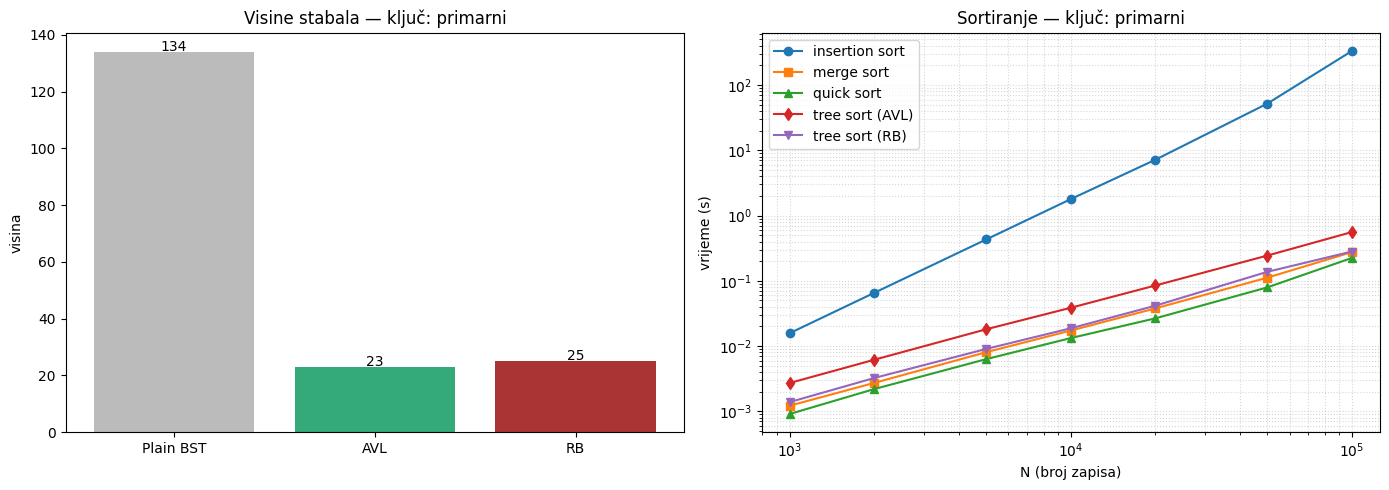

In [12]:
results_primarni = run_full_suite(
    key_label='primarni',
    records=records,
    plain_tree_cls=PlainPrimaryKeyTree,
    avl_tree_cls=PrimaryKeyTree,
    counting_tree_cls=CountingPrimaryKeyTree,
    rb_tree_cls=RBPrimaryKeyTree,
    key_fn=key_primary,
    prefix_examples=['Horvat', 'Horv*', 'Mar*', 'Iva*', 'Žagar'],
    range_examples=[('D', 'I'), ('Horv', 'Ivo'), ('Mar', 'Per')],
    sort_sizes=[1000, 2000, 5000, 10000, 20000, 50000, 100000],
    # insertion_sort_max=None znači: izvršavamo insertion sort i na 50k i 100k
    # iako je kvadratno spor (procijenjeno 50k≈45s, 100k≈3min — u skladu sa specifikacijom).
    insertion_sort_max=None,
    plot=True,
)


## 10) Zadatak i.1) Pokretanje za datum rođenja

Ponavljanje zadataka b)–h) s `datum_rodjenja` kao indeksnim
ključem. Prefiks `'1985*'` pronalazi sve rođene 1985. godine,
`'2000-01*'` sve rođene u siječnju 2000. itd.



INDEKSNI KLJUČ: datum    (N = 1000000 zapisa)

b) Izgradnja stabala


   Plain BST    : visina =   53, vrijeme = 11.052 s
   AVL          : visina =   23, vrijeme =  7.899 s
   RB stablo    : visina =   24, vrijeme =  4.764 s


   AVL property: OK

c) Minimalna i maksimalna vrijednost indeksa
   AVL min: Belić Gabriela (Ž, 1940-01-01, Hvar)
   AVL max: Šutić Matej (M, 2010-12-31, Umag)
   RB  min: Belić Gabriela (Ž, 1940-01-01, Hvar)
   RB  max: Šutić Matej (M, 2010-12-31, Umag)

d) Brojači rotacija pri izgradnji AVL stabla


   Lijeve rotacije :   349411
   Desne rotacije  :   349944
   Ukupno          :   699355
   (build s brojačima: 8.638 s — overhead ~ +9.4%)

e) Ispis stabla po razinama (prvih 10 razina)
--- Plain BST ---
Razina  0 [     1 čvorova]: 1961-12-20
Razina  1 [     2 čvorova]: 1942-09-03, 2000-09-16
Razina  2 [     4 čvorova]: 1941-09-30, 1948-09-04, 1994-01-03, 2008-06-30
Razina  3 [     8 čvorova]: 1941-04-28, 1941-11-20, 1943-11-24, 1960-11-19, 1964-12-15, 1998-04-21, 2001-09-26, 2009-08-13
Razina  4 [    16 čvorova]: 1940-09-13, 1941-06-16, 1941-11-14, 1942-02-14, 1943-09-07, 1947-01-26, 1958-10-18, 1961-02-06, 1962-02-15, 1977-11-30, 1997-01-11, 1999-04-29 ... (+4 jos, ukupno 16)
Razina  5 [    32 čvorova]: 1940-03-25, 1941-02-18, 1941-05-08, 1941-08-05, 1941-10-01, 1941-11-16, 1942-01-29, 1942-03-11, 1943-07-30, 1943-10-18, 1946-05-28, 1947-05-07 ... (+20 jos, ukupno 32)
Razina  6 [    64 čvorova]: 1940-03-25, 1940-09-08, 1940-10-04, 1941-02-22, 1941-05-03, 1941-06-04, 1941-06-30, 194

       5000       0.485s     0.008s     0.006s       0.017s       0.008s


      10000       1.931s     0.018s     0.013s       0.039s       0.018s


      20000       7.993s     0.040s     0.029s       0.085s       0.041s


      50000      64.117s     0.118s     0.088s       0.250s       0.124s


     100000     411.195s     0.274s     0.261s       0.576s       0.285s


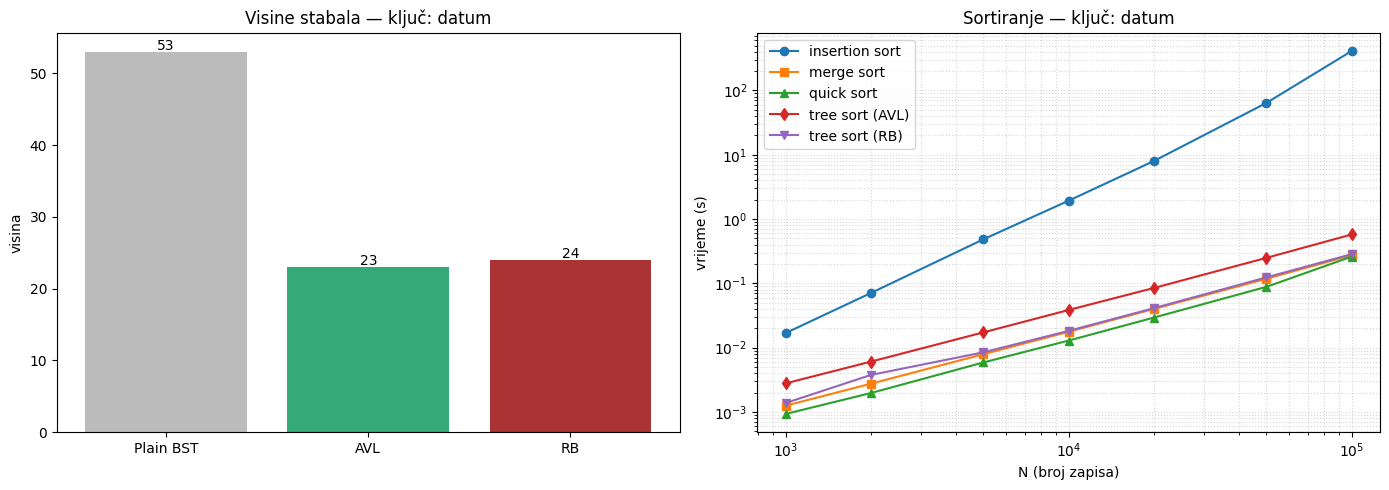

In [13]:
results_datum = run_full_suite(
    key_label='datum',
    records=records,
    plain_tree_cls=PlainDateKeyTree,
    avl_tree_cls=DateKeyTree,
    counting_tree_cls=CountingDateKeyTree,
    rb_tree_cls=RBDateKeyTree,
    key_fn=key_date,
    prefix_examples=['1985*', '2000-01*', '1970-06-15'],
    range_examples=[('1980', '1990'), ('1995-01', '1995-07'), ('2000', '2010')],
    sort_sizes=[1000, 2000, 5000, 10000, 20000, 50000, 100000],
    # insertion_sort_max=None znači: izvršavamo insertion sort i na 50k i 100k
    # iako je kvadratno spor (procijenjeno 50k≈45s, 100k≈3min — u skladu sa specifikacijom).
    insertion_sort_max=None,
    plot=True,
)


## 11) Zadatak i.2) Pokretanje za mjesto stanovanja

Ponavljanje zadataka b)–h) s `mjesto_stanovanja` kao indeksnim
ključem.



INDEKSNI KLJUČ: mjesto    (N = 1000000 zapisa)

b) Izgradnja stabala


   Plain BST    : visina =   49, vrijeme =  9.971 s
   AVL          : visina =   23, vrijeme =  7.430 s
   RB stablo    : visina =   23, vrijeme =  4.551 s


   AVL property: OK

c) Minimalna i maksimalna vrijednost indeksa
   AVL min: Antunac Adrian (M, 1960-08-13, Beli Manastir)
   AVL max: Žužić Šime (M, 1940-12-26, Žminj)
   RB  min: Antunac Adrian (M, 1960-08-13, Beli Manastir)
   RB  max: Žužić Šime (M, 1940-12-26, Žminj)

d) Brojači rotacija pri izgradnji AVL stabla


   Lijeve rotacije :   341234
   Desne rotacije  :   356074
   Ukupno          :   697308
   (build s brojačima: 8.324 s — overhead ~ +12.0%)

e) Ispis stabla po razinama (prvih 10 razina)
--- Plain BST ---
Razina  0 [     1 čvorova]: Opatija
Razina  1 [     2 čvorova]: Hrvatska Kostajnica, Vukovar
Razina  2 [     4 čvorova]: Buje, Metković, Ploče, Zadar
Razina  3 [     8 čvorova]: Bol, Dugo Selo, Lipik, Našice, Pag, Rovinj, Zadar, Čazma
Razina  4 [    16 čvorova]: Benkovac, Bol, Donji Miholjac, Garešnica, Kanfanar, Makarska, Metković, Našice, Opatija, Plitvička Jezera, Pula, Slatina ... (+4 jos, ukupno 16)
Razina  5 [    32 čvorova]: Belišće, Bjelovar, Bol, Bol, Daruvar, Dugo Selo, Funtana, Hrvatska Kostajnica, Ivanić-Grad, Križevci, Makarska, Mali Lošinj ... (+20 jos, ukupno 32)
Razina  6 [    64 čvorova]: Beli Manastir, Benkovac, Benkovac, Bol, Bol, Bol, Bol, Buje, Cavtat, Donja Stubica, Drniš, Dugo Selo ... (+52 jos, ukupno 64)
Razina  7 [   128 čvorova]: Beli Manastir, Belišće, Be

       5000       0.457s     0.008s     0.006s       0.018s       0.009s


      10000       1.861s     0.018s     0.014s       0.040s       0.019s


      20000       7.668s     0.040s     0.031s       0.088s       0.042s


      50000      57.684s     0.121s     0.106s       2.143s       0.126s


     100000     358.980s     0.284s     0.300s       0.587s       0.294s


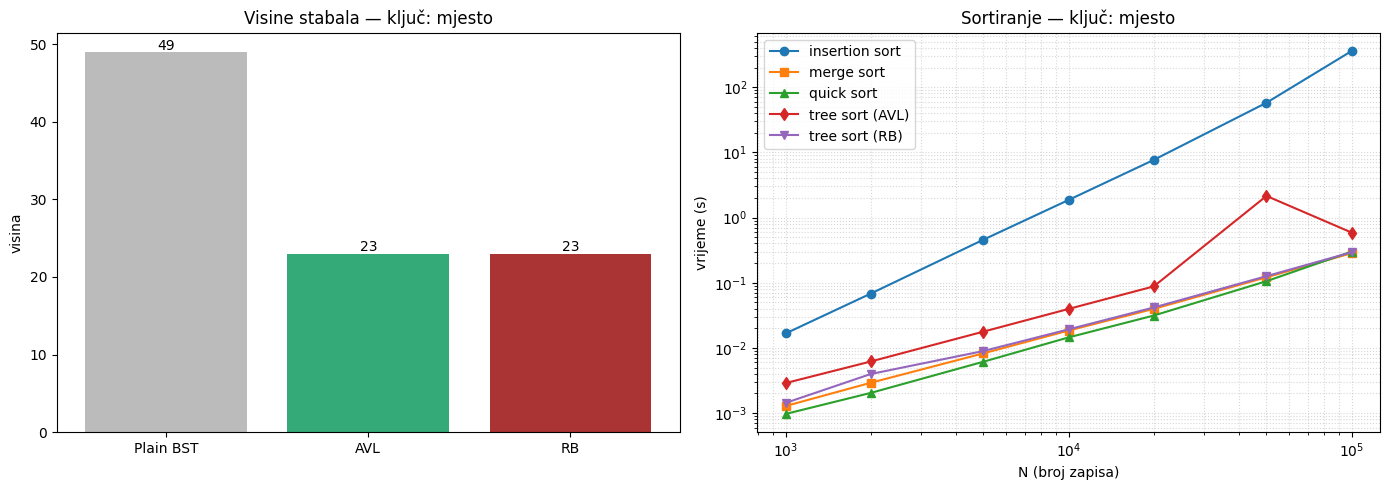

In [14]:
results_mjesto = run_full_suite(
    key_label='mjesto',
    records=records,
    plain_tree_cls=PlainCityKeyTree,
    avl_tree_cls=CityKeyTree,
    counting_tree_cls=CountingCityKeyTree,
    rb_tree_cls=RBCityKeyTree,
    key_fn=key_city,
    prefix_examples=['Z*', 'Sp*', 'Zagreb', 'Ri*'],
    range_examples=[('A', 'M'), ('R', 'Z'), ('Pula', 'Split')],
    sort_sizes=[1000, 2000, 5000, 10000, 20000, 50000, 100000],
    # insertion_sort_max=None znači: izvršavamo insertion sort i na 50k i 100k
    # iako je kvadratno spor (procijenjeno 50k≈45s, 100k≈3min — u skladu sa specifikacijom).
    insertion_sort_max=None,
    plot=True,
)
